# Experiment 1: learn representations

## Preliminary

In [330]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [331]:
# introduce the DKRL algorithm
import numpy as np
from tqdm import tqdm

def DKRL(y, KZ, KX, N, r, penalty, tol, T, wt = 0, verbose = 0):
    """
    Perform an double kernel representation learning.

    Parameters:
    y (numpy.ndarray): Target vector for optimization.
    KZ (numpy.ndarray): Kernel matrix Z.
    KX (numpy.ndarray): Kernel matrix X.
    N (int): Number of rows in U and V matrices.
    r (int): Number of columns in U and V matrices.
    penalty (float): Regularization parameter.
    tol (float): Tolerance for stopping criterion.
    T (int): Maximum number of iterations.
    wt (float): a number between 0 and 1 for adding identity to degenerate kernel matrix
    

    Returns:
    tuple: Final U and V matrices.
    """
    # Initialize U and V matrices randomly
    Ut = np.random.normal(loc=0, scale=1, size=(N, r))
    Vt = np.random.normal(loc=0, scale=1, size=(N, r))

    for iter in tqdm(range(T)):
        # Update U matrix
        VKX = np.repeat(np.dot(Vt.T, KX), repeats=N, axis=0)
        KZZ = np.tile(KZ, (1, r))
        DesignVt = VKX.T * KZZ  # n * (nr)
        Utt = np.linalg.solve(
            np.dot(DesignVt.T, DesignVt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KZ + wt * np.eye(N)),
            np.dot(DesignVt.T, y)
        )
        Utt = Utt.reshape((N, r), order="F")

        # Update V matrix
        UKZ = np.repeat(np.dot(Utt.T, KZ), repeats=N, axis=0)
        KXX = np.tile(KX, (1, r))
        DesignUt = UKZ.T * KXX  # n * (nr)
        Vtt = np.linalg.solve(
            np.dot(DesignUt.T, DesignUt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KX + wt * np.eye(N)),
            np.dot(DesignUt.T, y)
        )
        Vtt = Vtt.reshape((N, r), order="F")

        # Check stopping criterion
        norm_U = np.linalg.norm(Utt - Ut) / (np.linalg.norm(Ut) + 1e-3)
        norm_V = np.linalg.norm(Vtt - Vt) / (np.linalg.norm(Vt) + 1e-3)
        if verbose:
            print(f"Iteration {iter}: norm_U={norm_U}, norm_V={norm_V}")
        
        
        if norm_U < tol and norm_V < tol:
            break

        # Update Ut and Vt
        Ut = Utt
        Vt = Vtt

    y_pred = np.diag(KZ @ Utt @ Vtt.T @ KX)
    return Utt, Vtt, y_pred



In [332]:
def DKRL_pred(U, V, KZ_pred, KX_pred):
    y_pred = np.diag(KZ_pred.T @ U @ V.T @ KX_pred)
    return y_pred
    

## Simulate CTR data

In [333]:
# population parameters
N = 300
r = 2

the dimension of the embeddings is: 384


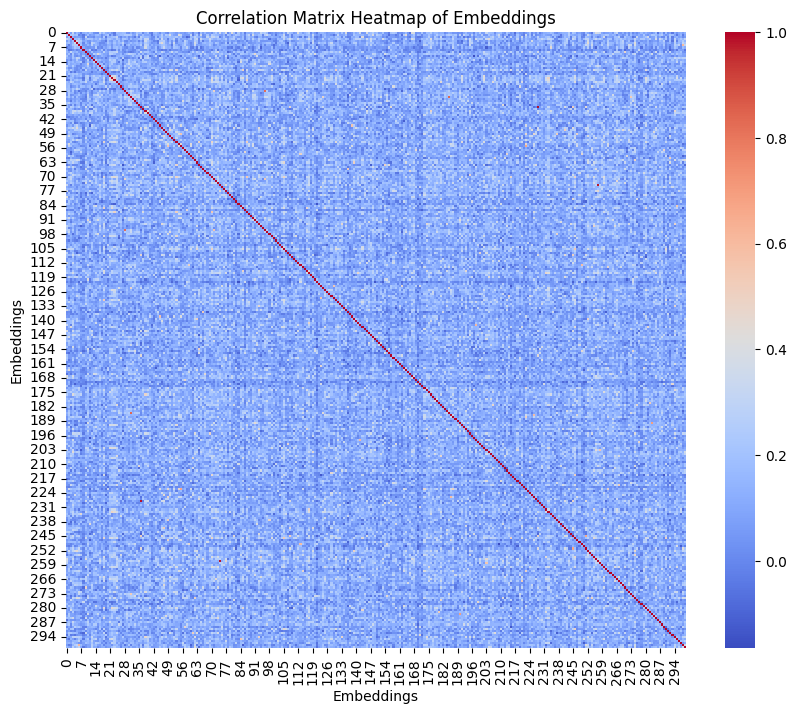

In [334]:
# import the headlines and embeddings

df = pd.read_csv("unique_headlines.csv")  # Replace with your file path
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')

# Randomly sample a subset of headlines and embeddings for evaluation
# Set a random seed for reproducibility
np.random.seed(2025)
ind = np.arange(len(headlines))  # Array with 1000 elements
sampled_ind = np.random.choice(ind, size=N, replace=False)

# Randomly sample 100 elements from the array
headlines = headlines[sampled_ind]
Z = embeddings[sampled_ind]

# dimension of the embeddings
p = len(Z[1])
print("the dimension of the embeddings is: " + str(len(Z[1])))

# visualize the embeddings
correlation_matrix = np.corrcoef(Z)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix Heatmap of Embeddings')
plt.xlabel('Embeddings')
plt.ylabel('Embeddings')
plt.show()

In [335]:
# Simulate covariate level features from Gaussian distributions
np.random.seed(2025)
q = 500
X = np.random.normal(loc=0, scale=1, size=(N, q))
row_norms_X = np.linalg.norm(X, axis=1, keepdims=True)
X = X / row_norms_X

In [336]:
# Simulate projection matrix
# generate random projection
np.random.seed(2025)
P = np.random.normal(loc=0, scale=1, size=(p, q))
L, S, Rt = np.linalg.svd(P, full_matrices=False)
Lr = L[:, :r]
Rr = Rt[:r, :].T

# generate the outcome
Zr = np.dot(Z, Lr) # n*r
Xr = np.dot(X, Rr) # n*r
y = np.diag(np.dot(Zr, Xr.T)) # + 0.01 * np.random.normal(loc = 0, scale = 1, )

## Reconstruct the signals

In [337]:
# Compute the kernel
KZ = np.dot(Z, Z.T)
KX = np.dot(X, X.T)
KZX = KZ * KX

# Split data into training and testing
N_train = 250
N_test = 50

np.random.seed(2025)
train_id = np.random.choice(range(N), size=N_train, replace=False)
test_id = np.array(list(set(range(N)) - set(train_id)))

# training data
KZ_train = KZ[np.ix_(train_id, train_id)]
KX_train = KX[np.ix_(train_id, train_id)]
KZX_train = KZX[np.ix_(train_id, train_id)]
y_train = y[train_id]

# testing data
KZ_test = KZ[np.ix_(train_id, test_id)]
KX_test = KX[np.ix_(train_id, test_id)]
KZX_test = KZX[np.ix_(train_id, test_id)]
y_test = y[test_id]

### Method 1: dkrl

In [338]:
# compute the kernels (simply with cosine similarity): 
penalty = 1e-4
tol = 1e-2
r = 2
T = 1000

In [339]:
np.random.seed(2025)
U, V, y_hat = DKRL(y_train, KZ_train, KX_train, N_train, r, penalty, tol, T, wt = 0)
y_pred = DKRL_pred(U, V, KZ_test, KX_test)

 32%|███▏      | 316/1000 [00:07<00:15, 44.15it/s]


In [340]:
print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/50))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/50))

7.887168167066276e-05
0.01019939270144538


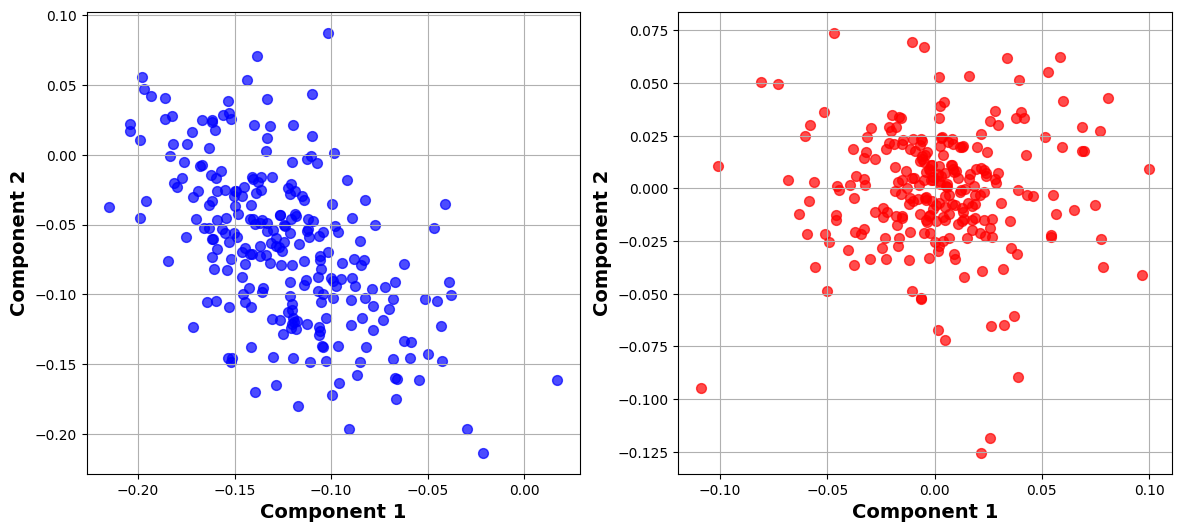

In [345]:
# find the representations
Urep = KZ_train @ U
Vrep = KX_train @ V
# labels=("Treatment representation", "X-representation")

# Extract x and y coordinates
x1, y1 = Urep[:, 0], Urep[:, 1]
x2, y2 = Vrep[:, 0], Vrep[:, 1]

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First subplot
axes[0].scatter(x1, y1, color='blue', alpha=0.7, s=50)
# axes[0].set_title(labels[0])
axes[0].set_xlabel("Component 1", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Component 2", fontsize=14, fontweight='bold')
axes[0].grid(True)

# Second subplot
axes[1].scatter(x2, y2, color='red', alpha=0.7, s=50)
# axes[1].set_title(labels[1])
axes[1].set_xlabel("Component 1", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Component 2", fontsize=14, fontweight='bold')
axes[1].grid(True)

plt.savefig("Components.png")

### Method 2: RKHS regression with only treatments

In [258]:
lambda_z = 0.5e-3
alpha = np.linalg.solve(KZ_train + lambda_z * np.eye(N_train), y_train)
y_hat = KZ_train @ alpha
y_pred = KZ_test.T @ alpha

print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/50))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/50))

0.00019038974164071787
0.020247532695742528


### Method 3: RKHS regression with only covariates

In [259]:
lambda_x = 1.5e-3
alpha = np.linalg.solve(KX_train + lambda_x * np.eye(N_train), y_train)
y_hat = KX_train @ alpha
y_pred = KX_test.T @ alpha

print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/50))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/50))

9.22485323050077e-05
0.01621230144153877


### Method 4: RKHS regression with both kernels

In [260]:
lambda_x = 1.5e-2
alpha = np.linalg.solve(KZX_train + lambda_x * np.eye(N_train), y_train)
y_hat = KZX_train @ alpha
y_pred = KZX_test.T @ alpha

print(np.sqrt(np.linalg.norm(y_train - y_hat)**2/50))
print(np.sqrt(np.linalg.norm(y_test - y_pred)**2/50))

0.0003417769022163405
0.011587519433327344


## Simulation runs

In [326]:
MC = int(100)  # Monte Carlo iterations
df = pd.read_csv("unique_headlines.csv")  # Load headlines
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')
np.random.seed(2025)

pt_level = np.array([5e-1, 1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4])

# Structured storage dictionary
results = {pt: {
    "DKRL": {"U": [], "V": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
    "KZ": {"alpha": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
    "KX": {"alpha": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
    "KZX": {"alpha": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
} for pt in pt_level}

for pt_iter, penalty in enumerate(pt_level):
    for iter in tqdm(range(MC), desc=f"Running MC Simulation for pt_level {penalty}"):
        # Randomly sample a subset of headlines and embeddings for evaluation
        ind = np.arange(len(headlines))  
        sampled_ind = np.random.choice(ind, size=N, replace=False)

        # Subsample headlines and embeddings
        headlines_sampled = headlines[sampled_ind]
        Z = embeddings[sampled_ind]

        # Dimension of embeddings
        p = len(Z[1])

        # Simulate covariate level features from Gaussian distributions
        q = 500
        X = np.random.normal(loc=0, scale=1, size=(N, q))
        X /= np.linalg.norm(X, axis=1, keepdims=True)

        # Simulate projection matrix
        P = np.random.normal(loc=0, scale=1, size=(p, q))
        L, S, Rt = np.linalg.svd(P, full_matrices=False)
        Lr, Rr = L[:, :r], Rt[:r, :].T

        # Generate the outcome
        Zr = np.dot(Z, Lr)
        Xr = np.dot(X, Rr)
        y = np.diag(np.dot(Zr, Xr.T))  

        # Compute the kernel
        KZ, KX = np.dot(Z, Z.T), np.dot(X, X.T)
        KZX = KZ * KX

        # Split data into training and testing
        N_train, N_test = 250, 50
        train_id = np.random.choice(range(N), size=N_train, replace=False)
        test_id = np.array(list(set(range(N)) - set(train_id)))

        # Training data
        KZ_train, KX_train, KZX_train = KZ[np.ix_(train_id, train_id)], KX[np.ix_(train_id, train_id)], KZX[np.ix_(train_id, train_id)]
        y_train = y[train_id]

        # Testing data
        KZ_test, KX_test, KZX_test = KZ[np.ix_(train_id, test_id)], KX[np.ix_(train_id, test_id)], KZX[np.ix_(train_id, test_id)]
        y_test = y[test_id]

        ## **Simulation**
        # **Method 1: DKRL**
        tol, r, T = 1e-2, 2, 1000
        U, V, y_hat = DKRL(y_train, KZ_train, KX_train, N_train, r, penalty/10, tol, T, wt=0.05)
        y_pred = DKRL_pred(U, V, KZ_test, KX_test)
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / 250)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / 50)

        # Store results
        results[penalty]["DKRL"]["U"].append(U)
        results[penalty]["DKRL"]["V"].append(V)
        results[penalty]["DKRL"]["y_hat"].append(y_hat)
        results[penalty]["DKRL"]["y_pred"].append(y_pred)
        results[penalty]["DKRL"]["train_err"].append(train_err)
        results[penalty]["DKRL"]["test_err"].append(test_err)

        # **Method 2: Use only KZ**
        alpha = np.linalg.solve(KZ_train + penalty * np.eye(N_train), y_train)
        y_hat, y_pred = KZ_train @ alpha, KZ_test.T @ alpha
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / 250)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / 50)

        # Store results
        results[penalty]["KZ"]["alpha"].append(alpha)
        results[penalty]["KZ"]["y_hat"].append(y_hat)
        results[penalty]["KZ"]["y_pred"].append(y_pred)
        results[penalty]["KZ"]["train_err"].append(train_err)
        results[penalty]["KZ"]["test_err"].append(test_err)

        # **Method 3: Use only KX**
        alpha = np.linalg.solve(KX_train + penalty * np.eye(N_train), y_train)
        y_hat, y_pred = KX_train @ alpha, KX_test.T @ alpha
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / 250)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / 50)

        # Store results
        results[penalty]["KX"]["alpha"].append(alpha)
        results[penalty]["KX"]["y_hat"].append(y_hat)
        results[penalty]["KX"]["y_pred"].append(y_pred)
        results[penalty]["KX"]["train_err"].append(train_err)
        results[penalty]["KX"]["test_err"].append(test_err)

        # **Method 4: Use both KZX**
        alpha = np.linalg.solve(KZX_train + penalty * np.eye(N_train), y_train)
        y_hat, y_pred = KZX_train @ alpha, KZX_test.T @ alpha
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / 250)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / 50)

        # Store results
        results[penalty]["KZX"]["alpha"].append(alpha)
        results[penalty]["KZX"]["y_hat"].append(y_hat)
        results[penalty]["KZX"]["y_pred"].append(y_pred)
        results[penalty]["KZX"]["train_err"].append(train_err)
        results[penalty]["KZX"]["test_err"].append(test_err)

# Save results
np.save("MC_simulation_results.npy", results)




Running MC Simulation for pt_level 0.0005: 100%|██████████| 100/100 [17:17<00:00, 10.38s/it]


### A Second experiment: sensitivity regarding the choice of ranks

In [329]:
MC = int(100)  # Monte Carlo iterations
df = pd.read_csv("unique_headlines.csv")  # Load headlines
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')
np.random.seed(2025)

r_level = np.array([2, 4, 6, 8, 10])

# Structured storage dictionary
results_rank = {r: {
    "DKRL": {"U": [], "V": [], "y_hat": [], "y_pred": [], "train_err": [], "test_err": []},
} for r in r_level}

for r_iter, r in enumerate(r_level):
    for iter in tqdm(range(MC), desc=f"Running MC Simulation for pt_level {penalty}"):
        # Randomly sample a subset of headlines and embeddings for evaluation
        ind = np.arange(len(headlines))  
        sampled_ind = np.random.choice(ind, size=N, replace=False)

        # Subsample headlines and embeddings
        headlines_sampled = headlines[sampled_ind]
        Z = embeddings[sampled_ind]

        # Dimension of embeddings
        p = len(Z[1])

        # Simulate covariate level features from Gaussian distributions
        q = 500
        X = np.random.normal(loc=0, scale=1, size=(N, q))
        X /= np.linalg.norm(X, axis=1, keepdims=True)

        # Simulate projection matrix
        P = np.random.normal(loc=0, scale=1, size=(p, q))
        L, S, Rt = np.linalg.svd(P, full_matrices=False)
        Lr, Rr = L[:, :2], Rt[:2, :].T

        # Generate the outcome
        Zr = np.dot(Z, Lr)
        Xr = np.dot(X, Rr)
        y = np.diag(np.dot(Zr, Xr.T))  

        # Compute the kernel
        KZ, KX = np.dot(Z, Z.T), np.dot(X, X.T)
        KZX = KZ * KX

        # Split data into training and testing
        N_train, N_test = 250, 50
        train_id = np.random.choice(range(N), size=N_train, replace=False)
        test_id = np.array(list(set(range(N)) - set(train_id)))

        # Training data
        KZ_train, KX_train, KZX_train = KZ[np.ix_(train_id, train_id)], KX[np.ix_(train_id, train_id)], KZX[np.ix_(train_id, train_id)]
        y_train = y[train_id]

        # Testing data
        KZ_test, KX_test, KZX_test = KZ[np.ix_(train_id, test_id)], KX[np.ix_(train_id, test_id)], KZX[np.ix_(train_id, test_id)]
        y_test = y[test_id]

        ## **Simulation**
        # **Method 1: DKRL**
        tol, T = 1e-2, 1000
        U, V, y_hat = DKRL(y_train, KZ_train, KX_train, N_train, r, penalty, tol, T, wt=0.05)
        y_pred = DKRL_pred(U, V, KZ_test, KX_test)
        train_err = np.sqrt(np.linalg.norm(y_train - y_hat)**2 / 250)
        test_err = np.sqrt(np.linalg.norm(y_test - y_pred)**2 / 50)

        # Store results
        results_rank[r]["DKRL"]["U"].append(U)
        results_rank[r]["DKRL"]["V"].append(V)
        results_rank[r]["DKRL"]["y_hat"].append(y_hat)
        results_rank[r]["DKRL"]["y_pred"].append(y_pred)
        results_rank[r]["DKRL"]["train_err"].append(train_err)
        results_rank[r]["DKRL"]["test_err"].append(test_err)

    

# Save results
np.save("MC_simulation_results_rank.npy", results_rank)

Running MC Simulation for pt_level 0.0005: 100%|██████████| 100/100 [20:18<00:00, 12.18s/it]
